In [5]:
!pip install h2o pandas matplotlib

import h2o
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

h2o.init(max_mem_size='8G')
print("Установка завершена")

  Using cached h2o-3.46.0.9-py2.py3-none-any.whl.metadata (2.1 kB)
Using cached h2o-3.46.0.9-py2.py3-none-any.whl (266.0 MB)
Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "17.0.17" 2025-10-21; OpenJDK Runtime Environment (build 17.0.17+10-Ubuntu-122.04); OpenJDK 64-Bit Server VM (build 17.0.17+10-Ubuntu-122.04, mixed mode, sharing)
  Starting server from /usr/local/lib/python3.12/dist-packages/h2o/backend/bin/h2o.jar
  Ice root: /tmp/tmpl90q6lqp
  JVM stdout: /tmp/tmpl90q6lqp/h2o_unknownUser_started_from_python.out
  JVM stderr: /tmp/tmpl90q6lqp/h2o_unknownUser_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,03 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.9
H2O_cluster_version_age:,20 days
H2O_cluster_name:,H2O_from_python_unknownUser_xzykmd
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,8 Gb
H2O_cluster_total_cores:,2
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"


Установка завершена


In [14]:
file_path = '/content/telemetry_data.csv'  # Замените
df = pd.read_csv(file_path)

/tmp/ipython-input-488910972.py:2: DtypeWarning: Columns (52) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


In [15]:
# Датасет представляет собой собираемые раз в 1 десятую секунды данные телеметрии с каждой машиной в сессии. Всего 20 машин, в каждой по 1 пилоту.

df.head(40).style.set_table_styles([
    {'selector': 'tr:nth-of-type(odd)', 'props': [('background', '#f0f0f0')]},
    {'selector': 'th', 'props': [('background', '#d0d0d0'), ('font-weight', 'bold')]}
]).set_caption("Первые строки датасета")

,sessionTime,frameIdentifier,pilot_index,worldPositionX,worldPositionY,worldPositionZ,worldVelocityX,worldVelocityY,worldVelocityZ,worldForwardDirX,worldForwardDirY,worldForwardDirZ,worldRightDirX,worldRightDirY,worldRightDirZ,gForceLateral,gForceLongitudinal,gForceVertical,yaw,pitch,roll,speed,throttle,steer,brake,clutch,gear,engineRPM,drs,brakesTemperature,tyresSurfaceTemperature,tyresInnerTemperature,engineTemperature,tyresPressure,surfaceType,fuelMix,pitLimiterStatus,fuelInTank,fuelRemainingLaps,tyresWear,actualTyreCompound,tyresDamage,ersStoreEnergy,ersDeployMode,ersHarvestedThisLapMGUK,ersHarvestedThisLapMGUH,ersDeployedThisLap,carPosition,currentLapTime,currentLapNum,lapDistance,totalDistance,pitStatus,sector,driverStatus,resultStatus
0,0.009620,0,0,-582.574890,-139.235630,755.828550,0.002150,-0.001620,-0.002390,26335,-106,19495,-19495,-3,26336,0.075300,-0.002760,-0.032460,0.933550,0.002540,0.000110,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3481.000000,0.000000,28/28/28/28,84/84/89/89,84/84/89/89,90.000000,21.500/21.500/23.000/23.000,0/0/0/0,2.000000,0.000000,58.249000,2.634880,0.000/0.000/0.000/0.000,soft,0.000/0.000/0.000/0.000,4000000.000000,2.000000,0.000000,0.000000,0.000000,15,0.000000,1,166.226260,166.226260,nan,0,on track,active
1,0.009620,0,1,-492.976680,-139.239180,822.492490,0.000940,0.001270,0.002900,26352,-114,19473,-19473,-1,26352,-0.078200,-0.001350,-0.002100,0.934400,0.002780,0.000040,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4281.000000,0.000000,28/28/28/28,84/84/89/89,84/84/89/89,90.000000,21.500/21.500/23.000/23.000,0/0/0/0,2.000000,0.000000,55.525760,1.221850,0.000/0.000/0.000/0.000,soft,0.000/0.000/0.000/0.000,4000000.000000,1.000000,0.000000,0.000000,0.000000,1,0.000000,1,277.915220,277.915220,nan,0,on track,active
2,0.009620,0,2,-521.042720,-139.249250,793.212220,0.001490,0.002850,0.003710,26354,-114,19470,-19470,-1,26354,-0.084290,-0.000370,-0.001040,0.934490,0.002780,0.000040,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3481.000000,0.000000,28/28/28/28,84/84/89/89,84/84/89/89,90.000000,21.500/21.500/23.000/23.000,0/0/0/0,2.000000,0.000000,56.920510,1.948640,0.000/0.000/0.000/0.000,soft,0.000/0.000/0.000/0.000,4000000.000000,2.000000,0.000000,0.000000,0.000000,6,0.000000,1,237.742080,237.742080,nan,0,on track,active
3,0.009620,0,3,-559.293090,-139.244540,764.746460,-0.000580,0.001520,0.001960,26356,-111,19468,-19468,9,26356,-0.069200,0.003210,0.013830,0.934600,0.002910,-0.000290,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3781.000000,0.000000,28/28/28/28,84/84/89/89,84/84/89/89,90.000000,21.500/21.500/23.000/23.000,0/0/0/0,2.000000,0.000000,56.526450,1.732600,0.000/0.000/0.000/0.000,soft,0.000/0.000/0.000/0.000,4000000.000000,2.000000,0.000000,0.000000,0.000000,12,0.000000,1,190.066450,190.066450,nan,0,on track,active
4,0.009620,0,4,-518.660220,-139.238820,803.418700,-0.000770,0.000820,0.003780,26354,-114,19471,-19471,-7,26354,-0.041280,0.008470,0.004320,0.934480,0.002680,0.000220,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4281.000000,0.000000,28/28/28/28,84/84/89/89,84/84/89/89,90.000000,21.500/21.500/23.000/23.000,0/0/0/0,2.000000,0.000000,56.084360,1.510050,0.000/0.000/0.000/0.000,soft,0.000/0.000/0.000/0.000,4000000.000000,2.000000,0.000000,0.000000,0.000000,5,0.000000,1,245.921070,245.921070,nan,0,on track,active
5,0.009620,0,5,-556.896420,-139.231170,774.936580,-0.001790,0.000810,0.003520,26347,-105,19480,-19480,-6,26347,-0.068150,0.003950,0.017460,0.934130,0.002460,0.000190,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3781.000000,0.000000,28/28/28/28,84/84/89/89,84/84/89/89,90.000000,21.500/21.500/23.000/23.000,0/0/0/0,2.000000,0.000000,58.391560,2.715720,0.000/0.000/0.000/0.000,soft,0.000/0.000/0.000/0.000,4000000.000000,2.000000,0.000000,0.000000,0.000000,11,0.000000,1,198.237230,198.237230,nan,0,on track,active
6,0.009620,0,6,-569.733030,-139.241210,765.371830,0.002570,-0.001370,-0.003050,26354,-109,19470,-19470,2,26354,0.07

In [17]:
import numpy as np

In [19]:
categorical_cols = ['pilot_index', 'gear', 'drs', 'surfaceType', 'actualTyreCompound',
                    'ersDeployMode', 'pitStatus', 'sector', 'driverStatus', 'resultStatus',
                    'fuelMix', 'pitLimiterStatus']
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype('category')

df = df.sort_values(['pilot_index', 'sessionTime']).reset_index(drop=True)

def parse_tyres_wear(x):
    if pd.isna(x):
        return np.nan
    try:
        values = [float(v) for v in str(x).split('/')]
        return np.mean(values)
    except:
        return np.nan

df['tyresWear_mean'] = df['tyresWear'].apply(parse_tyres_wear)

print("Примеры tyresWear_mean:")
print(df[['tyresWear', 'tyresWear_mean']].head(10))
print(f"\nСтатистика износа шин: {df['tyresWear_mean'].describe()}")

df['prev_throttle'] = df.groupby('pilot_index')['throttle'].shift(1)
df['prev_brake'] = df.groupby('pilot_index')['brake'].shift(1)
df['prev_gForceLateral'] = df.groupby('pilot_index')['gForceLateral'].shift(1)
df['prev_gForceLongitudinal'] = df.groupby('pilot_index')['gForceLongitudinal'].shift(1)

df = df.dropna(subset=['tyresWear_mean']).reset_index(drop=True)
df = df.dropna().reset_index(drop=True)

split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]

train = h2o.H2OFrame(train_df)
test = h2o.H2OFrame(test_df)

target = 'tyresWear_mean'

print(f"\nTarget: {target} (средний износ шин в %)")
print(f"Min: {train[target].min()}, Max: {train[target].max()}, Mean: {train[target].mean()}")

to_remove = [target, 'tyresWear', 'tyresDamage',
             'frameIdentifier', 'sessionTime',
             'worldPositionX', 'worldPositionY', 'worldPositionZ',
             'worldForwardDirX', 'worldForwardDirY', 'worldForwardDirZ',
             'worldRightDirX', 'worldRightDirY', 'worldRightDirZ',
             'currentLapTime', 'currentLapNum', 'lapDistance', 'totalDistance',
             'carPosition', 'driverStatus', 'resultStatus']

features = [col for col in train.columns if col not in to_remove]

print(f"Количество признаков: {len(features)}")

train[target] = train[target].asnumeric()
test[target] = test[target].asnumeric()

Примеры tyresWear_mean:
                     tyresWear  tyresWear_mean
0  42.000/39.000/42.000/37.000            40.0
1  42.000/39.000/42.000/37.000            40.0
2  42.000/39.000/42.000/37.000            40.0
3  42.000/39.000/42.000/37.000            40.0
4  42.000/39.000/42.000/37.000            40.0
5  42.000/39.000/42.000/37.000            40.0
6  42.000/39.000/42.000/37.000            40.0
7  42.000/39.000/42.000/37.000            40.0
8  42.000/39.000/42.000/37.000            40.0
9  42.000/39.000/42.000/37.000            40.0

Статистика износа шин: count    14140.000000
mean        20.797825
std         20.565741
min          0.000000
25%          0.000000
50%         30.500000
75%         39.750000
max         53.250000
Name: tyresWear_mean, dtype: float64


/tmp/ipython-input-2820303780.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['prev_throttle'] = df.groupby('pilot_index')['throttle'].shift(1)
/tmp/ipython-input-2820303780.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['prev_brake'] = df.groupby('pilot_index')['brake'].shift(1)
/tmp/ipython-input-2820303780.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['prev_gForceLateral'] = df.groupby('pilo

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%

Target: tyresWear_mean (средний износ шин в %)
Min: 0.0, Max: 53.25, Mean: [21.06285410764869]
Количество признаков: 40


In [21]:
from h2o.automl import H2OAutoML

aml = H2OAutoML(
    max_models=15,
    max_runtime_secs=1200,  # 20 минут — износ сложнее
    seed=42,
    sort_metric='RMSE'
)

aml.train(x=features, y=target, training_frame=train, validation_frame=test)

print("=== Лидерборд ===")
print(aml.leaderboard.head(rows=aml.leaderboard.nrows))

AutoML progress: |
13:46:54.566: User specified a validation frame with cross-validation still enabled. Please note that the models will still be validated using cross-validation only, the validation frame will be used to provide purely informative validation metrics on the trained models.
13:46:54.586: _train param, Dropping bad and constant columns: [engineTemperature, drs, clutch, tyresPressure, gear]

██████
13:48:30.588: _train param, Dropping bad and constant columns: [engineTemperature, drs, clutch, tyresPressure, gear]

██████
13:50:25.570: _train param, Dropping bad and constant columns: [engineTemperature, drs, clutch, tyresPressure, gear]

███
13:51:15.94: _train param, Dropping bad and constant columns: [engineTemperature, drs, clutch, tyresPressure, gear]

██
13:51:54.662: _train param, Dropping bad and constant columns: [engineTemperature, drs, clutch, tyresPressure, gear]

█
13:52:12.430: _train param, Dropping bad and constant columns: [engineTemperature, drs, clutch, t

Лучшая модель: StackedEnsemble_AllModels_1_AutoML_2_20251215_134654
stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%

Первые 10 предсказаний среднего износа шин (%):


/usr/local/lib/python3.12/dist-packages/h2o/job.py:81: UserWarning: Test/Validation dataset column 'brakesTemperature' has levels not trained on: ["1000/1002/1001/1004", "1001/1001/1009/1008", "1002/1004/1004/1006", "1003/1005/1006/1008", "1004/1004/1012/1011", "1005/1006/1007/1010", "1006/1006/1015/1014", "1006/1008/1009/1012", "1008/1009/1011/1014", "1009/1009/1018/1018", ...1662 not listed..., "995/995/1007/1007", "995/997/994/996", "996/995/1007/1008", "996/996/1006/1006", "996/998/996/998", "997/997/1008/1008", "997/997/1009/1010", "998/998/1006/1005", "998/999/998/1000", "999/1001/1000/1002"]
  warnings.warn(w)
/usr/local/lib/python3.12/dist-packages/h2o/job.py:81: UserWarning: Test/Validation dataset column 'tyresSurfaceTemperature' has levels not trained on: ["73/74/80/80", "73/75/80/84", "73/75/81/83", "73/76/79/82", "73/76/80/82", "73/76/81/83", "74/74/80/80", "74/74/81/80", "74/74/84/83", "74/74/84/85", ...77 not listed..., "84/84/93/93", "84/84/94/94", "84/85/94/94", "84/90

  predict
  44.072
  43.5285
  44.2162
  43.7884
  43.9754
  43.9342
  44.0201
  43.9433
  42.9928
  43.6162
[10 rows x 1 column]


=== Метрики ===
ModelMetricsRegressionGLM: stackedensemble
** Reported on test data. **

MSE: 6.551528489184417
RMSE: 2.559595376067166
MAE: 1.6101733062688268
RMSLE: NaN
Mean Residual Deviance: 6.551528489184417
R^2: 0.9842420524076803
Null degrees of freedom: 2823
Residual degrees of freedom: 2814
Null deviance: 1180269.7041430485
Residual deviance: 18501.516453456792
AIC: 13344.433059392053
Export File progress: |██████████████████████████████████████████████████████████| (done) 100%
Export File progress: |██████████████████████████████████████████████████████████| (done) 100%

R² score: 0.9842

=== Важность признаков ===
Varimp из базовой модели: GBM_3_AutoML_2_20251215_134654


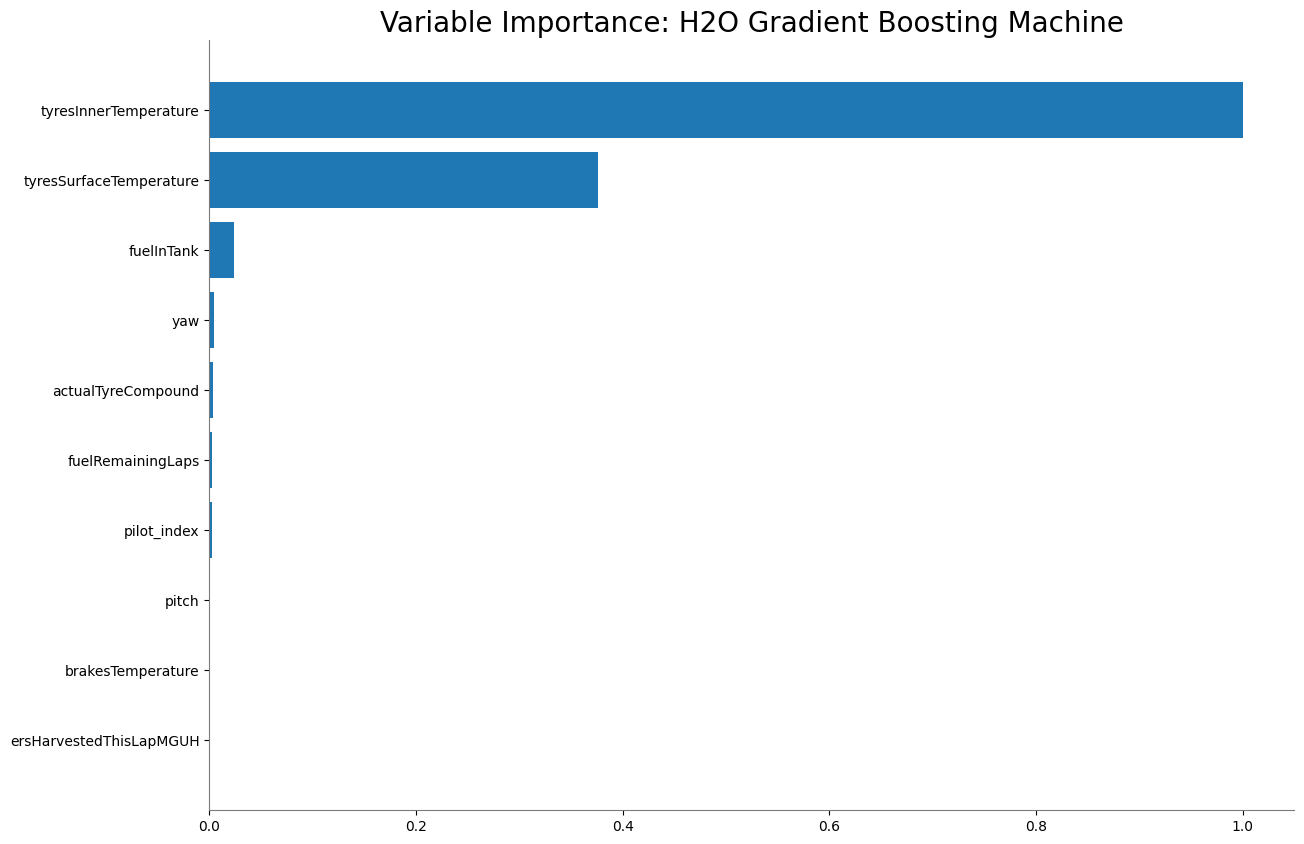

                  variable  relative_importance  scaled_importance  percentage
0    tyresInnerTemperature         1.766303e+07           1.000000    0.706221
1  tyresSurfaceTemperature         6.639436e+06           0.375895    0.265464
2               fuelInTank         4.225389e+05           0.023922    0.016894
3                      yaw         8.776397e+04           0.004969    0.003509
4       actualTyreCompound         6.957603e+04           0.003939    0.002782
5        fuelRemainingLaps         5.203421e+04           0.002946    0.002080
6              pilot_index         5.036968e+04           0.002852    0.002014
7                    pitch         1.187399e+04           0.000672    0.000475
8        brakesTemperature         5.617514e+03           0.000318    0.000225
9  ersHarvestedThisLapMGUH         3.830355e+03           0.000217    0.000153


<Figure size 640x480 with 0 Axes>

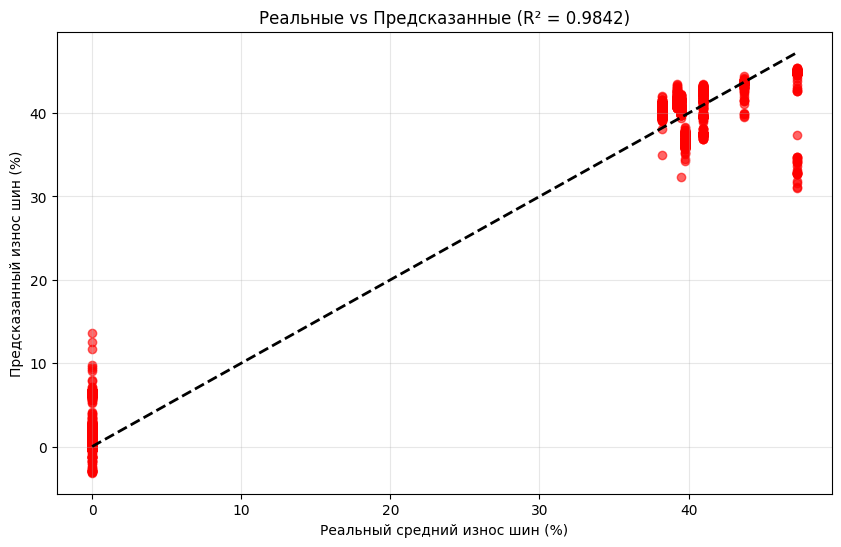

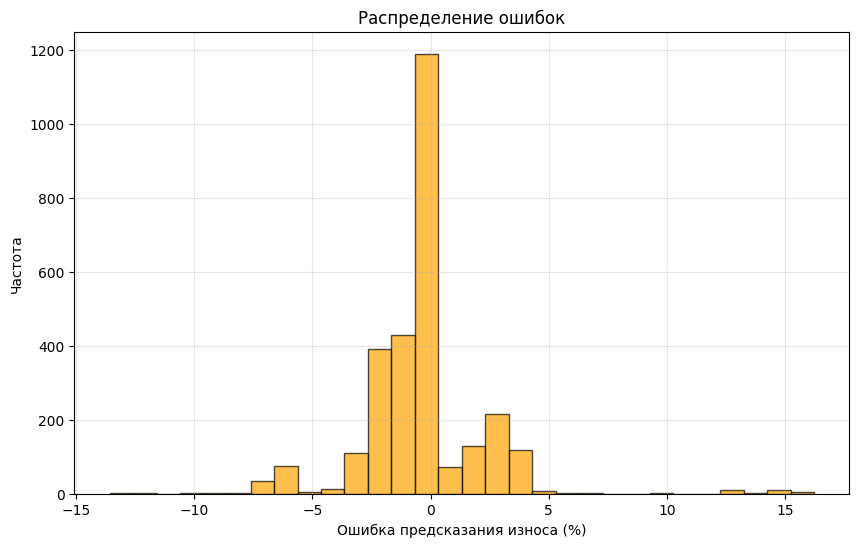

In [22]:
leader = aml.leader
print(f"Лучшая модель: {leader.model_id}")

preds = leader.predict(test)
print("\nПервые 10 предсказаний среднего износа шин (%):")
print(preds.head(10))

perf = leader.model_performance(test)
print("\n=== Метрики ===")
print(perf)

test_pd = test.as_data_frame(use_multi_thread=True)
preds_pd = preds.as_data_frame(use_multi_thread=True)

r2 = r2_score(test_pd[target], preds_pd['predict'])
print(f"\nR² score: {r2:.4f}")

print("\n=== Важность признаков ===")
if 'stackedensemble' in leader.model_id.lower():
    for i in range(aml.leaderboard.nrows):
        model_id = aml.leaderboard[i, 'model_id']
        if 'stackedensemble' not in model_id.lower():
            base_model = h2o.get_model(model_id)
            print(f"Varimp из базовой модели: {model_id}")
            if hasattr(base_model, 'varimp_plot'):
                base_model.varimp_plot()
            print(base_model.varimp(use_pandas=True).head(10))
            break
else:
    leader.varimp_plot()
    print(leader.varimp(use_pandas=True).head(10))

plt.figure(figsize=(10,6))
plt.scatter(test_pd[target], preds_pd['predict'], alpha=0.6, color='red')
plt.plot([test_pd[target].min(), test_pd[target].max()],
         [test_pd[target].min(), test_pd[target].max()], 'k--', lw=2)
plt.xlabel('Реальный средний износ шин (%)')
plt.ylabel('Предсказанный износ шин (%)')
plt.title(f'Реальные vs Предсказанные (R² = {r2:.4f})')
plt.grid(True, alpha=0.3)
plt.show()

residuals = test_pd[target] - preds_pd['predict']
plt.figure(figsize=(10,6))
plt.hist(residuals, bins=30, edgecolor='black', alpha=0.7, color='orange')
plt.xlabel('Ошибка предсказания износа (%)')
plt.ylabel('Частота')
plt.title('Распределение ошибок')
plt.grid(True, alpha=0.3)
plt.show()